Coding section for MA2K4 assignment 4 for u2242223 and u5505419

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Question 4.7

[]

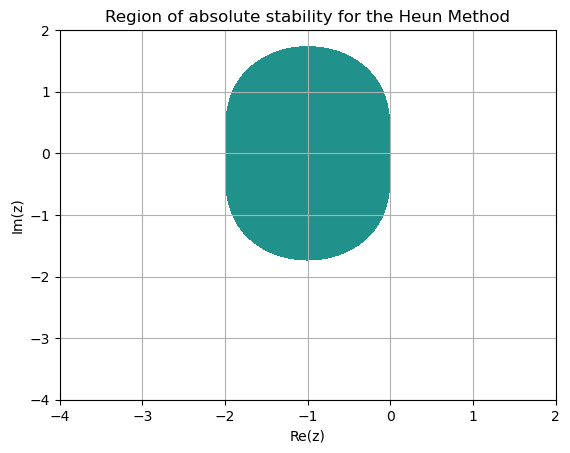

In [8]:
#Creating linspaces for a subset of the complex plane


x = np.linspace(-4,2,1000) #x-axis
y = np.linspace(-4,2,1000) #y-axis
X, Y = np.meshgrid(x,y) 
Z = X + 1j*Y #Complex Plane 

R = 1 + Z + 0.5 * Z**2 #We need the absolute value of this function to be less than one as from Q4.2, using each value from the complex plane as defined

#Plotting the region neccessary

plt.contourf(X,Y, np.abs(R), levels = [0,1]) #Using contourf to fill the regions between the level sets of 0, and 1, the region we want
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Region of absolute stability for the Heun Method')
plt.grid(True)
plt.plot()


This region is the region of absolute stability (excluding the boundary). It is clearly not A-stable since it does not cover the whole of $\mathbb{C}^-$, specifically, $z = -3 - 2i$ is not in our region as an example point.

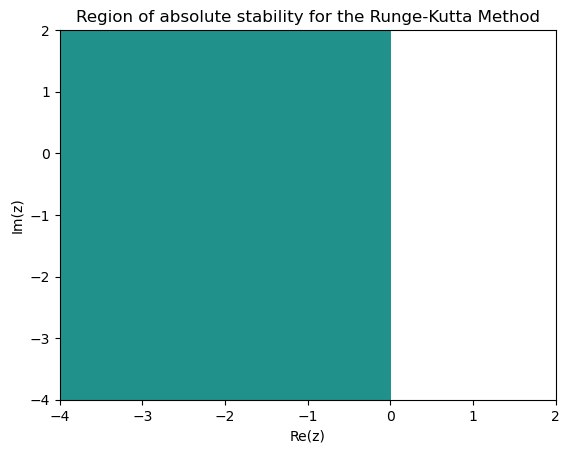

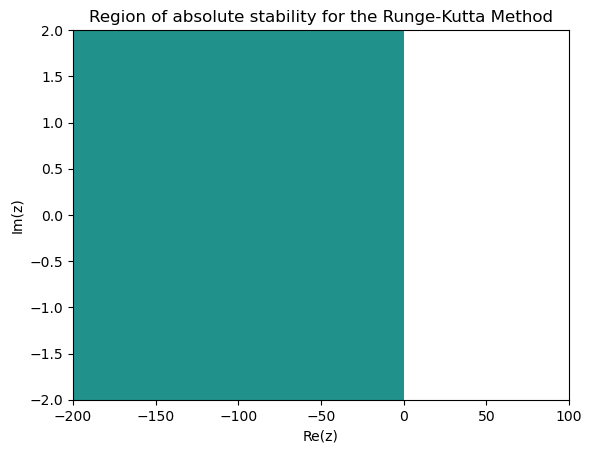

In [3]:
#Defining Runge-Kutta stability from 4.6 (with z = \lambda * h

Q_num = 1 + 0.5*Z + (1/12)*Z**2
Q_den = 1 - 0.5*Z + (1/12)*Z**2
Q = Q_num / Q_den
plt.contourf(X,Y, np.abs(Q), levels = [0,1])
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Region of absolute stability for the Runge-Kutta Method')
plt.show()

#We define a bigger negative region to check for A-Stability of the Runge- Kutta

a = np.linspace(-200, 100, 1000)
b = np.linspace(-2, 2, 1000)
A, B = np.meshgrid(a,b)
Z_large = A + 1j*B

Q_num_large = 1 + 0.5*Z_large + (1/12)*Z_large**2
Q_den_large = 1 - 0.5*Z_large + (1/12)*Z_large**2
Q_large = Q_num_large / Q_den_large


plt.contourf(A,B, np.abs(Q_large), levels = [0,1])
plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.title('Region of absolute stability for the Runge-Kutta Method')
plt.show()


We cannot say with certainty whether the Runge-Kutta method is A-stable from this contour plot, but we can say that for large number such as z = -200, the entirety of $\mathbb{C}^-$ is contained in the absolute stability region, making it very likely that the Runge-Kutta method is A-stable. 

Question 4.8

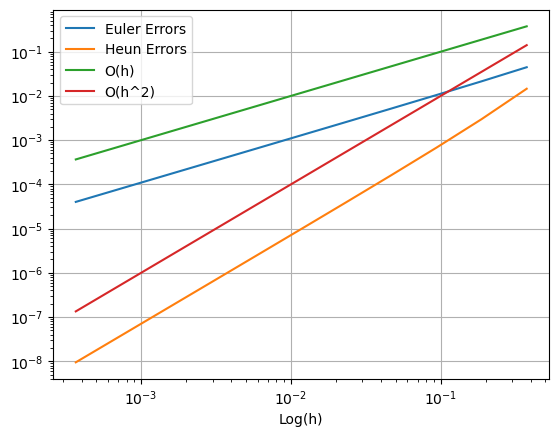

In [4]:
from ode_methods_a4 import f, exact_solution, evolve, last_error, EOC, k_values, h_values, N_values, errors, Euler, Heun

euler_errors = errors(Euler, h_values, N_values) #creating forward euler method error and eoc arrays
euler_eoc = EOC(h_values, euler_errors)

heun_errors = errors(Heun, h_values, N_values) #creating heun method error and eoc arrays
heun_eoc = EOC(h_values, heun_errors)

O_h2_values = [h**2 for h in h_values] #creating h^2 values for the plot (theoretical eoc of heun method)


#Plotting on loglog to see the EOC of each method, and see if it aligns with our table of values later
plt.loglog(h_values, euler_errors, label='Euler Errors')
plt.loglog(h_values, heun_errors, label='Heun Errors')
plt.loglog(h_values, h_values, label='O(h)')
plt.loglog(h_values, O_h2_values, label='O(h^2)')
plt.xlabel('Log(h)')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import pandas as pd #importing pandas to create a table to show the EOC of both the Heun and Forward Euler Methods (used in previous assignments and okay by the forum)

#creating our set of data
data = {
    "h":h_values,
    "Euler EOC": euler_eoc,
    "Heun EOC": heun_eoc
}
table = pd.DataFrame(data) #creating the table as taught in MA124
#rounding each column
table["h"] = table["h"].round(4)
table["Euler EOC"] = table["Euler EOC"].round(4)
table["Heun EOC"] = table["Heun EOC"].round(4)

print(table)

         h  Euler EOC  Heun EOC
0   0.3750        NaN       NaN
1   0.1875     1.0576    2.2844
2   0.0938     1.0295    2.1384
3   0.0469     1.0148    2.0666
4   0.0234     1.0074    2.0325
5   0.0117     1.0037    2.0161
6   0.0059     1.0018    2.0080
7   0.0029     1.0009    2.0040
8   0.0015     1.0005    2.0020
9   0.0007     1.0002    2.0010
10  0.0004     1.0001    2.0005


For the forward Euler method we see that, in the table, the EOC is approaching 1 as h decreases. This aligns with the plot, where the Euler errors have the same gradient as $h^1$ on a log-log plot. Similarly, for the Heun method, in the table, the EOC approaches 2 as h decreases. This agrees with our plot, where the Heun errors have the same gradient as $h^2$ on a log-log plot.

Question 4.9

/var/folders/23/_66cf27j24xb_tzlq5131w5m0000gn/T/ipykernel_99449/3987375886.py:6: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  u_i = u + h * np.sum(A[i][j] * K[j] for j in range(i+1)) #second function entry in definition of K_i, but we only sum to i since the matrix is lower-triangular, hence every other entry is zero.
/var/folders/23/_66cf27j24xb_tzlq5131w5m0000gn/T/ipykernel_99449/3987375886.py:8: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  Phi = np.sum(K[i] * b[i] for i in range(s))


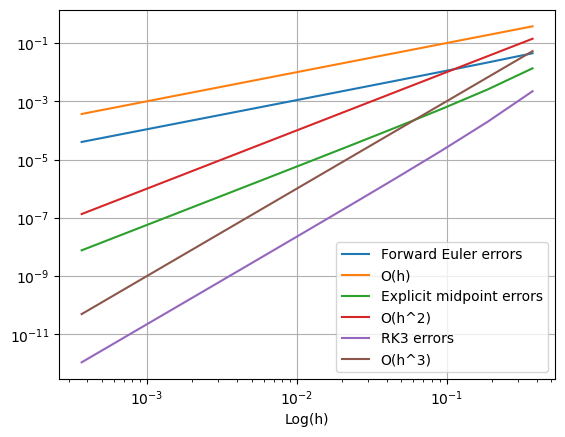

In [6]:
from explicit_runge_kutta_a4 import explicitRK

#Definining each method in the question using the matrices and vectors given, and then applying explicitRK
from explicit_runge_kutta_a4 import forwardeuler, explicit_midpoint, RK3

#using functions from 4.8 with our new increment functions
f_euler_errors = errors(forwardeuler, h_values, N_values) 
explicit_midpoint_errors = errors(explicit_midpoint, h_values, N_values)
rk3_errors = errors(RK3, h_values, N_values)

O_h3_values = [h**3 for h in h_values] #defining h**3 values for our plot

#plotting log-log graph for each method and their corresponding expected orders

plt.loglog(h_values, f_euler_errors, label='Forward Euler errors')
plt.loglog(h_values, h_values, label='O(h)')

plt.loglog(h_values, explicit_midpoint_errors, label='Explicit midpoint errors')
plt.loglog(h_values, O_h2_values, label='O(h^2)')

plt.loglog(h_values, rk3_errors, label='RK3 errors')
plt.loglog(h_values, O_h3_values, label='O(h^3)')

plt.xlabel('Log(h)')
plt.legend()
plt.grid(True)
plt.show()



We see that the gradient of the forward euler method errors matches the gradient of O(h) and hence the the method has order 1. The same applies for the explicit midpoint method and RK3 with O(h^2) and O(h^3) respectively as their gradients match in both cases. Since the forward euler method is a stage 1 method, the explicit midpoint method is a stage 2 method, and RK3 is a stage 3 method, it is possible in theory that the number of stages of an explicit Runge Kutta method is the same as its experimental order of convergence.

/var/folders/23/_66cf27j24xb_tzlq5131w5m0000gn/T/ipykernel_99449/1550436433.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  u_i = u + h* np.sum(A[i][j]*K[j] for j in range(i)) + h* A[i][i]*x
/var/folders/23/_66cf27j24xb_tzlq5131w5m0000gn/T/ipykernel_99449/1550436433.py:12: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return np.sum(b[i] * K[i] for i in range(s))


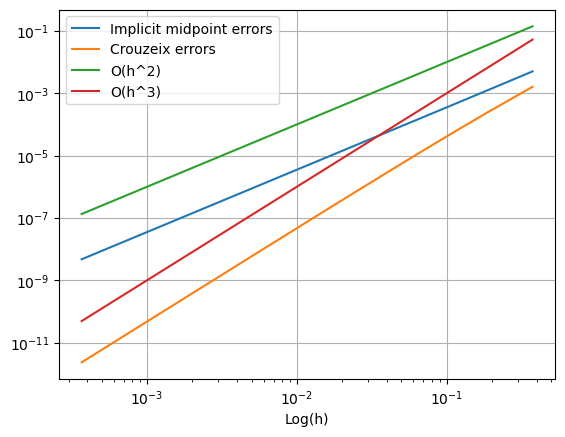

In [7]:
from scipy.optimize import root_scalar #importing what is required in the question

from implicit_runge_kutta_a4 import DIRK


#repeating what we did for a) but with different methods and using DIRK instead of explicitRK
from implicit_runge_kutta_a4 import implicit_midpoint, crouzeix

#using functions from 4.8 to create an array of errors for each method
implicit_midpoint_errors = errors(implicit_midpoint, h_values, N_values)
crouzeix_errors = errors(crouzeix, h_values, N_values)

plt.loglog(h_values, implicit_midpoint_errors, label='Implicit midpoint errors')
plt.loglog(h_values, crouzeix_errors, label='Crouzeix errors')
plt.loglog(h_values, O_h2_values, label='O(h^2)')
plt.loglog(h_values, O_h3_values, label='O(h^3)')

plt.xlabel('Log(h)')
plt.legend()
plt.grid(True)
plt.show()

The plot of implicit midpoint errors has the same gradient on a log-log plot as $h^2$, hence we conclude graphically that the implicit midpoint method has order 2. Similarly, the plot of Crouzeix errors has the same gradient as $h^3$ on a log-log plot, so we conclude it has order 3, as expected from the question. Since these methods are stage 1 and 2 respectively, and have orders 2 and 3 respectively, we conclude that our observations for explicit Runge-Kutta methods does not hold (since number of stages $\neq$ orders for these methods). We observe that it is possible for diagonally implicit Runge-Kutta methods to have order $s + 1$, where is the number of stages for the method.